\
# DDPM — math, with visualizations

A guided walk through the DDPM math using **2D toy data** so you can *see* every concept on a plot. The math we use is the same as on the page; only the data lives in 2 dimensions instead of in pixel space. This lets us draw scatter plots of the data distribution, the noised distribution, and the reverse process.

Companion to **`day2/ddpm_paper_tutorial.md`** (the prose walkthrough of the paper). Read the tutorial first if you want the high-level story; this notebook is the **"with my notebook and a pen" deep-dive** on the math, with every formula visualized.

**How to use this notebook.** Open a real notebook (paper kind). For each section:
1. Read the math explanation.
2. Look at the plot.
3. Try to re-derive the equation on paper. The text is verbose specifically so you can check each step.

**Source paper.** Ho, Jain, Abbeel (NeurIPS 2020), [arXiv 2006.11239](https://arxiv.org/abs/2006.11239).


## Setup

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0); np.random.seed(0)
DEVICE = "cpu"   # everything here is tiny; no GPU needed


\
## Section 1 — Probability notation, demystified

The DDPM paper uses notation that's standard in probability theory but can feel opaque if you haven't seen it before. Three things to ground:

### 1.1 — A probability distribution is a function, not a number

When the paper writes $q(x_0)$, it does not mean "the value of $q$ at $x_0$." It means **the distribution itself**, viewed as a function that takes any candidate value and returns its probability density.

> Think of $q$ as a function: $q: \mathbb{R}^d \to \mathbb{R}_{\geq 0}$. Plug in any value $x$, get a non-negative number.

For images, $d$ is the number of pixels × channels. For us in this notebook, $d = 2$ — easier to visualize.

The notation $x_0 \sim q(x_0)$ means "$x_0$ is *drawn* (sampled) from the distribution $q$." In code, this is `x_0 = sample(q)`.

### 1.2 — Why the subscript "0" in $x_0$?

The "0" is **a step index in a chain**, not an exponent or a power. The DDPM paper defines a chain of variables:

$$x_0, x_1, x_2, \ldots, x_T$$

- $x_0$ is the **clean original image** (step 0 — no noise added yet).
- $x_1$ is the same image after one tiny noise step.
- $x_T$ is the same image after $T$ noise steps — essentially pure noise.

So $q(x_0)$ specifically denotes the distribution of the clean data (step-0 of the chain). $q(x_t)$ would be the distribution of the *noisy* version at step $t$.

### 1.3 — The Gaussian notation $\mathcal{N}(x; \mu, \Sigma)$

For a **scalar (1D)** Gaussian:
$$\mathcal{N}(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\,\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

The arguments mean:
- The first argument $x$ is **where we're evaluating** the density.
- The second argument $\mu$ is **the mean** (where the distribution is centered).
- The third argument $\sigma^2$ is **the variance** (how wide the distribution is).

For a **multivariate (vector)** Gaussian:
$$\mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \Sigma) = \frac{1}{\sqrt{(2\pi)^d\,|\Sigma|}}\,\exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol{\mu})\right)$$

Now:
- $\mathbf{x}$ is a $d$-dimensional vector.
- $\boldsymbol{\mu}$ is also a $d$-dimensional vector (the mean *vector*).
- $\Sigma$ is a $d \times d$ **covariance matrix** — *not* a single number anymore.

**Why a matrix?** Because for multivariate distributions you have to describe not just how much each dimension varies, but *how dimensions correlate*. The $(i, j)$ entry of $\Sigma$ is the covariance between $x_i$ and $x_j$.

### 1.4 — "Why is the identity matrix a parameter?"

In the paper, equation 2 says:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\bigl(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I\bigr)$$

The covariance is $\beta_t I$ where $I$ is the **identity matrix** and $\beta_t$ is a scalar. Concretely for $d = 2$:

$$\beta_t I = \beta_t \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = \begin{pmatrix} \beta_t & 0 \\ 0 & \beta_t \end{pmatrix}$$

So the covariance matrix is **diagonal** with $\beta_t$ on every diagonal entry. This means **two things at once**:
1. Each dimension has variance $\beta_t$ (the diagonal entries).
2. The off-diagonal entries are 0 → **no correlations between dimensions** → noise on each pixel is independent of noise on every other pixel.

This kind of "diagonal with equal entries" covariance is called **isotropic**. It's the simplest possible noise: independent and equal across every dimension.

For images, "isotropic" means **every pixel gets its own independent Gaussian noise sample, all with the same variance**. Very different from, say, blurring (which would correlate neighboring pixels — represented by a non-diagonal $\Sigma$).

So when the paper writes "$\Sigma = \beta_t I$," it's not a strange parameter — it's just shorthand for "independent Gaussian noise of the same variance on every dimension." We'll visualize this on 2D data below.

### 1.5 — $q$ vs $p_\theta$

Just a naming convention:
- $q$ = the **true** distribution (data, forward process). Unknown explicitly — we only have samples.
- $p_\theta$ = our **model**, parameterized by neural network weights $\theta$. We can evaluate and sample it.

That's it. They're both probability distributions; we just use different symbols to keep track of which is the *target* (data) and which is the *model* we're training.


\
## Section 2 — Visualize $q(x_0)$ as 2D spiral data

To *see* every concept in this paper, we replace high-dimensional images with **2D toy data**. We pick a spiral shape: each "data point" is a 2D vector $x = (x_1, x_2) \in \mathbb{R}^2$. The distribution $q(x_0)$ is then a 2D scatter cloud shaped like a spiral.

This serves the same role as a high-resolution image dataset, but small enough to plot.


x0_data: shape=torch.Size([2000, 2]) (2000 points, 2 dims)  range=[-2.03, 2.16]


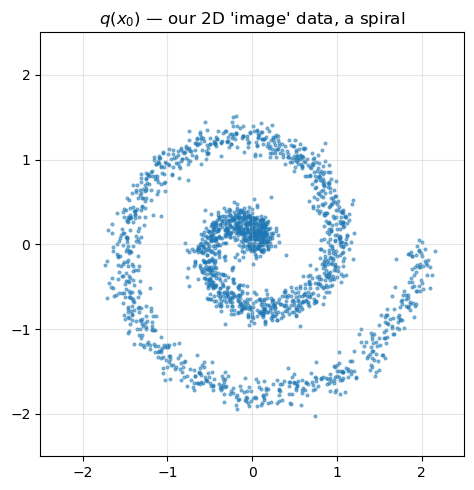

In [2]:
def make_spiral(n=1000, noise=0.05):
    """2D spiral data. n points, with a small bit of noise so the spiral has thickness."""
    theta = torch.linspace(0, 4 * math.pi, n)
    r = theta / (4 * math.pi)                  # radius grows with theta
    x = r * torch.cos(theta) + noise * torch.randn(n)
    y = r * torch.sin(theta) + noise * torch.randn(n)
    return torch.stack([x, y], dim=1) * 2.0    # scale to make it visible

torch.manual_seed(0)
x0_data = make_spiral(2000)
print(f"x0_data: shape={x0_data.shape} (2000 points, 2 dims)  range=[{x0_data.min():.2f}, {x0_data.max():.2f}]")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x0_data[:, 0], x0_data[:, 1], s=4, alpha=0.5)
ax.set_title(r"$q(x_0)$ — our 2D 'image' data, a spiral")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()


Each dot is one "data sample" $x_0$. The whole cloud, taken together, *is* the distribution $q(x_0)$ — a probability distribution that gives high density to points on the spiral and near-zero density everywhere else. We never have $q$ as an explicit function; we only have these samples (just like we only have CIFAR-10 images, not the equations behind them).


\
## Section 3 — What does $\mathcal{N}(0, I)$ look like in 2D?

Before we touch the forward process, let's see what "isotropic Gaussian noise" actually looks like — the building block of all the noising operations.

For a 2D vector $\varepsilon \sim \mathcal{N}(0, I)$ where $I = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$:
- The mean is $(0, 0)$ — centered at the origin.
- The covariance is $I$ — variance 1 in each dimension, no correlation between dimensions.

In code: just `torch.randn(N, 2)`. Each dimension is independently sampled from a standard Gaussian.


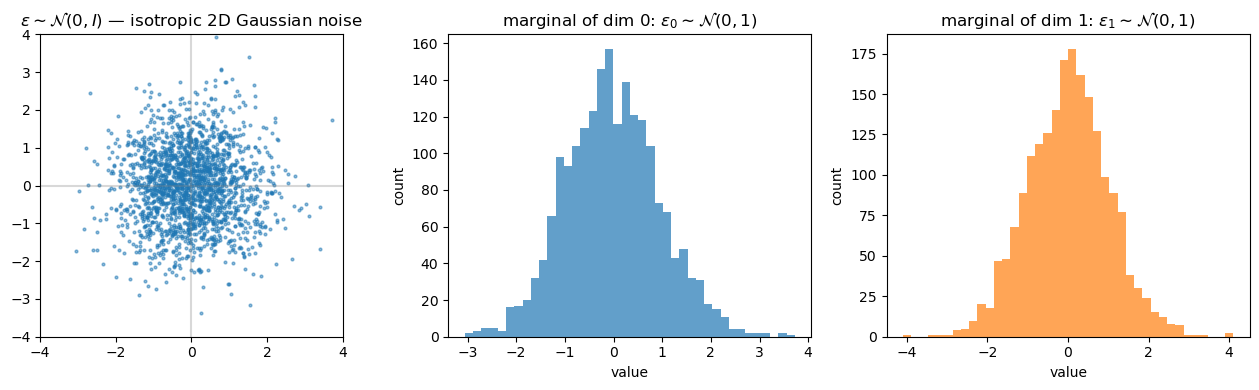

per-dim mean:     [-0.01995633  0.00679126]     (expected: [0, 0])
per-dim variance: [0.94843423 1.0254749 ]      (expected: [1, 1])
covariance (off-diagonal): 0.0072   (expected: 0)


In [3]:
torch.manual_seed(0)
eps_samples = torch.randn(2000, 2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(eps_samples[:, 0], eps_samples[:, 1], s=4, alpha=0.5)
axes[0].set_title(r"$\varepsilon \sim \mathcal{N}(0, I)$ — isotropic 2D Gaussian noise")
axes[0].set_aspect("equal"); axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].axhline(0, color='gray', alpha=0.3); axes[0].axvline(0, color='gray', alpha=0.3)

axes[1].hist(eps_samples[:, 0].numpy(), bins=40, color="tab:blue", alpha=0.7)
axes[1].set_title(r"marginal of dim 0: $\varepsilon_0 \sim \mathcal{N}(0, 1)$")
axes[1].set_xlabel("value"); axes[1].set_ylabel("count")

axes[2].hist(eps_samples[:, 1].numpy(), bins=40, color="tab:orange", alpha=0.7)
axes[2].set_title(r"marginal of dim 1: $\varepsilon_1 \sim \mathcal{N}(0, 1)$")
axes[2].set_xlabel("value"); axes[2].set_ylabel("count")
plt.tight_layout(); plt.show()

# Sanity checks
print(f"per-dim mean:     {eps_samples.mean(0).numpy()}     (expected: [0, 0])")
print(f"per-dim variance: {eps_samples.var(0).numpy()}      (expected: [1, 1])")
print(f"covariance (off-diagonal): {torch.cov(eps_samples.T)[0, 1].item():.4f}   (expected: 0)")


\
Read the plot top-to-bottom:
- Left: a blob centered at $(0, 0)$ with circular symmetry. The circular shape is because covariance is the *identity matrix* (same variance in both dimensions, no correlation).
- Middle / right: each dimension by itself is a standard Gaussian.

If the covariance had been, say, $\begin{pmatrix} 4 & 0 \\ 0 & 0.25 \end{pmatrix}$, the blob would have been wide in $x$ and narrow in $y$ — an ellipse, not a circle. The "isotropic" in $\mathcal{N}(0, \sigma^2 I)$ just means "same in every direction."

**This is the noise we add at every forward step in DDPM.** When the paper says "$\beta_t I$" — it just means this same blob, scaled by $\sqrt{\beta_t}$.


\
## Section 4 — Per-step forward $q(x_t \mid x_{t-1})$, visualized

Paper equation 2:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\bigl(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I\bigr)$$

In sampling form:
$$x_t = \underbrace{\sqrt{1-\beta_t}}_{\text{shrink}}\,x_{t-1} + \underbrace{\sqrt{\beta_t}\,\varepsilon}_{\text{add noise}}, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

Two operations per step:
- **Shrink:** multiply $x_{t-1}$ by $\sqrt{1-\beta_t} < 1$. Pulls the data toward 0.
- **Add isotropic noise:** add $\sqrt{\beta_t}\,\varepsilon$.

Watch this happen on the spiral with $\beta = 0.05$ (one big step, exaggerated for visibility).


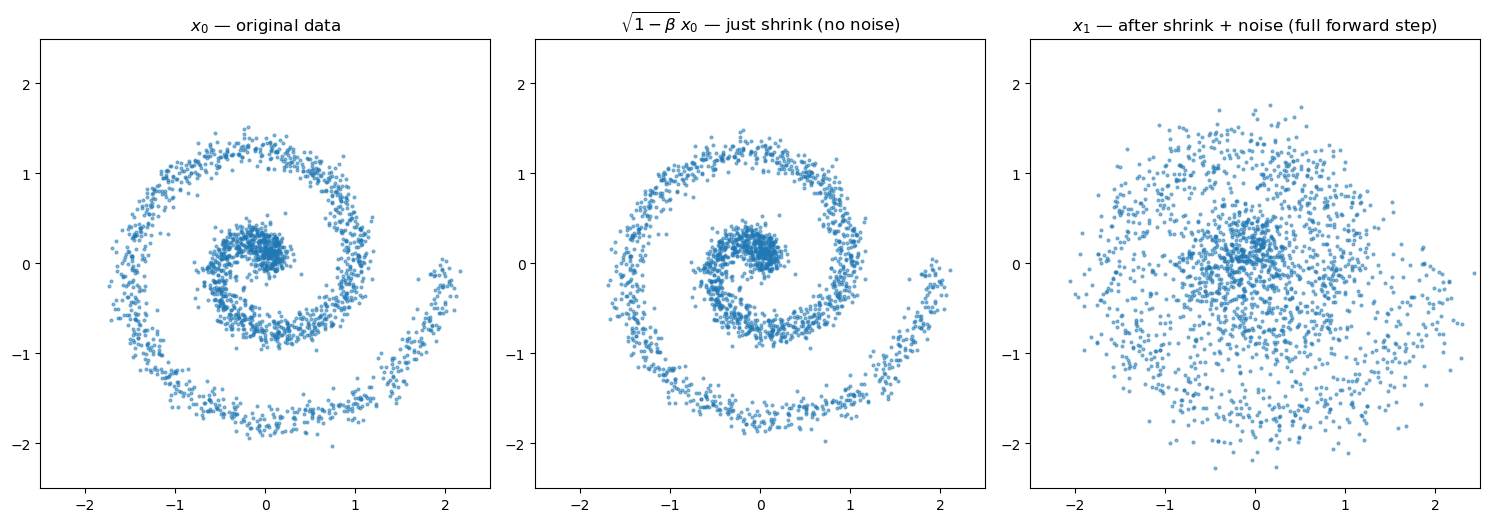

In [4]:
def per_step_forward(x_prev, beta):
    eps = torch.randn_like(x_prev)
    return torch.sqrt(1 - beta) * x_prev + torch.sqrt(beta) * eps

torch.manual_seed(0)
beta_demo = torch.tensor(0.05)            # large beta to make the change visible

x0 = x0_data
x_shrunk = torch.sqrt(1 - beta_demo) * x0  # shrink only (no noise)
x1 = per_step_forward(x0, beta_demo)      # full forward step

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(x0[:, 0], x0[:, 1], s=4, alpha=0.5)
axes[0].set_title(r"$x_0$ — original data");           axes[0].set_aspect("equal"); axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)

axes[1].scatter(x_shrunk[:, 0], x_shrunk[:, 1], s=4, alpha=0.5)
axes[1].set_title(r"$\sqrt{1-\beta}\,x_0$ — just shrink (no noise)"); axes[1].set_aspect("equal"); axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)

axes[2].scatter(x1[:, 0], x1[:, 1], s=4, alpha=0.5)
axes[2].set_title(r"$x_1$ — after shrink + noise (full forward step)"); axes[2].set_aspect("equal"); axes[2].set_xlim(-2.5, 2.5); axes[2].set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()


\
The middle plot shows the spiral **slightly contracted** toward the origin (because $\sqrt{1-0.05} \approx 0.975 < 1$). The right plot adds the noise — the spiral becomes a "fuzzy spiral." After many such steps the structure disappears entirely.

### Why this specific shrink-then-noise form? Variance preservation.

Claim: if $x_{t-1}$ has variance 1 (unit-variance data), then $x_t$ also has variance 1. This is why the chain doesn't explode in magnitude or collapse to zero.

**Proof on paper (write this with me):**
- $x_t = \sqrt{1 - \beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon$
- Take variance of both sides. Variance is additive for independent terms.
- $\text{Var}(x_t) = (\sqrt{1-\beta_t})^2 \cdot \text{Var}(x_{t-1}) + (\sqrt{\beta_t})^2 \cdot \text{Var}(\varepsilon)$
- $= (1-\beta_t) \cdot 1 + \beta_t \cdot 1 = 1$

Verify numerically below — should print near 1.0 for any $\beta$.


In [5]:
torch.manual_seed(0)
x_prev_test = torch.randn(50_000, 2)    # unit-variance start
for beta in [0.001, 0.01, 0.1, 0.5]:
    x_t_test = per_step_forward(x_prev_test, torch.tensor(beta))
    print(f"beta={beta:.3f}   var(x_prev)={x_prev_test.var().item():.4f}   "
          f"var(x_t)={x_t_test.var().item():.4f}   (theory: 1.0)")


beta=0.001   var(x_prev)=1.0025   var(x_t)=1.0022   (theory: 1.0)
beta=0.010   var(x_prev)=1.0025   var(x_t)=1.0023   (theory: 1.0)
beta=0.100   var(x_prev)=1.0025   var(x_t)=1.0036   (theory: 1.0)
beta=0.500   var(x_prev)=1.0025   var(x_t)=1.0039   (theory: 1.0)


\
## Section 5 — Watch the spiral dissolve into noise

Now run the full forward process: $T = 1000$ steps with the linear schedule $\beta_1 = 10^{-4}$ to $\beta_T = 0.02$. We snapshot the data at several timesteps.

**What you're watching:** at each $t$, a different "noised version" of the spiral. The visible structure dissolves; by $t = T$ it should be indistinguishable from $\mathcal{N}(0, I)$ — a circular blob.


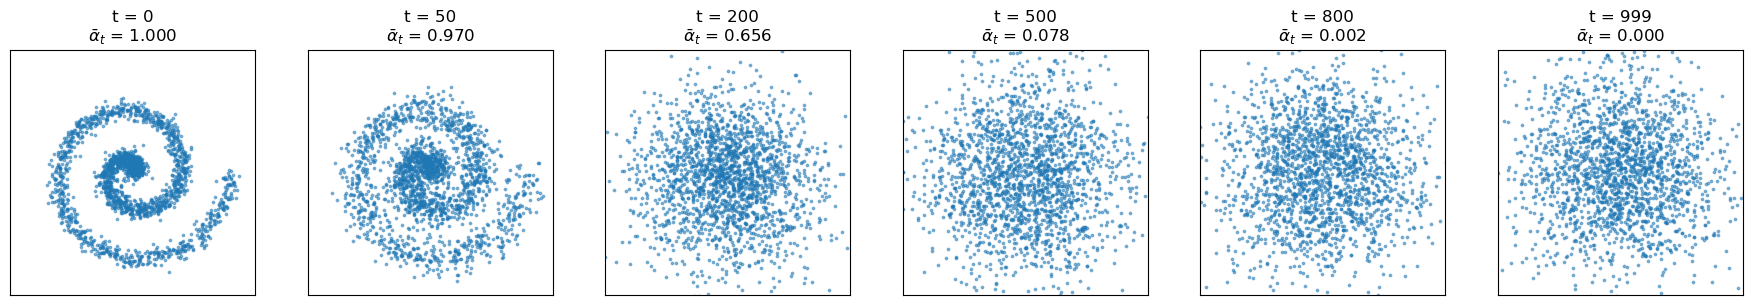

In [6]:
T = 1000
betas = torch.linspace(1e-4, 2e-2, T)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# Iterate the full forward chain. Save snapshots at several t.
torch.manual_seed(0)
snapshots = {}
snapshot_t = [0, 50, 200, 500, 800, 999]
x = x0_data.clone()
for t in range(T):
    if t in snapshot_t:
        snapshots[t] = x.clone()
    x = per_step_forward(x, betas[t])
snapshots[T-1] = x.clone()

fig, axes = plt.subplots(1, len(snapshot_t), figsize=(3 * len(snapshot_t), 3))
for ax, t in zip(axes, snapshot_t):
    s = snapshots[t]
    ax.scatter(s[:, 0], s[:, 1], s=3, alpha=0.5)
    ax.set_title(f"t = {t}\n" + r"$\bar\alpha_t$" + f" = {alpha_bars[t].item():.3f}")
    ax.set_aspect("equal"); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


\
What you're seeing:

- **$t = 0$**: pristine spiral, $\bar\alpha_t \approx 1$ (full signal).
- **$t = 50$**: still a spiral, just slightly noisier. $\bar\alpha_t \approx 0.995$.
- **$t = 200$**: spiral still visible but blurred. $\bar\alpha_t \approx 0.7$.
- **$t = 500$**: shape mostly gone. $\bar\alpha_t \approx 0.05$.
- **$t = 800$, $t = 999$**: roughly circular blob, basically standard Gaussian.

The signal scale $\bar\alpha_t$ printed in each title tracks exactly what fraction of the original data remains. By $t = 999$ it's near zero — pure noise.


\
## Section 6 — The closed-form forward (paper equation 4), visualized

The big trick: instead of iterating $t$ steps to get $x_t$ from $x_0$, sample directly in one shot.

Paper equation 4:
$$q(x_t \mid x_0) = \mathcal{N}\!\bigl(x_t;\ \sqrt{\bar\alpha_t}\,x_0,\ (1 - \bar\alpha_t)\,I\bigr)$$

Sample form:
$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1 - \bar\alpha_t}\,\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

This has the **same shape** as one forward step (shrink + add isotropic noise) but with **cumulative coefficients**:
- $\sqrt{\bar\alpha_t}$ in place of $\sqrt{1-\beta_t}$ — the cumulative shrink.
- $\sqrt{1 - \bar\alpha_t}$ in place of $\sqrt{\beta_t}$ — the cumulative noise.

**Verify on plot:** generate $x_t$ at the same timesteps using the closed form, and compare to the iterative snapshots. They should look statistically the same.


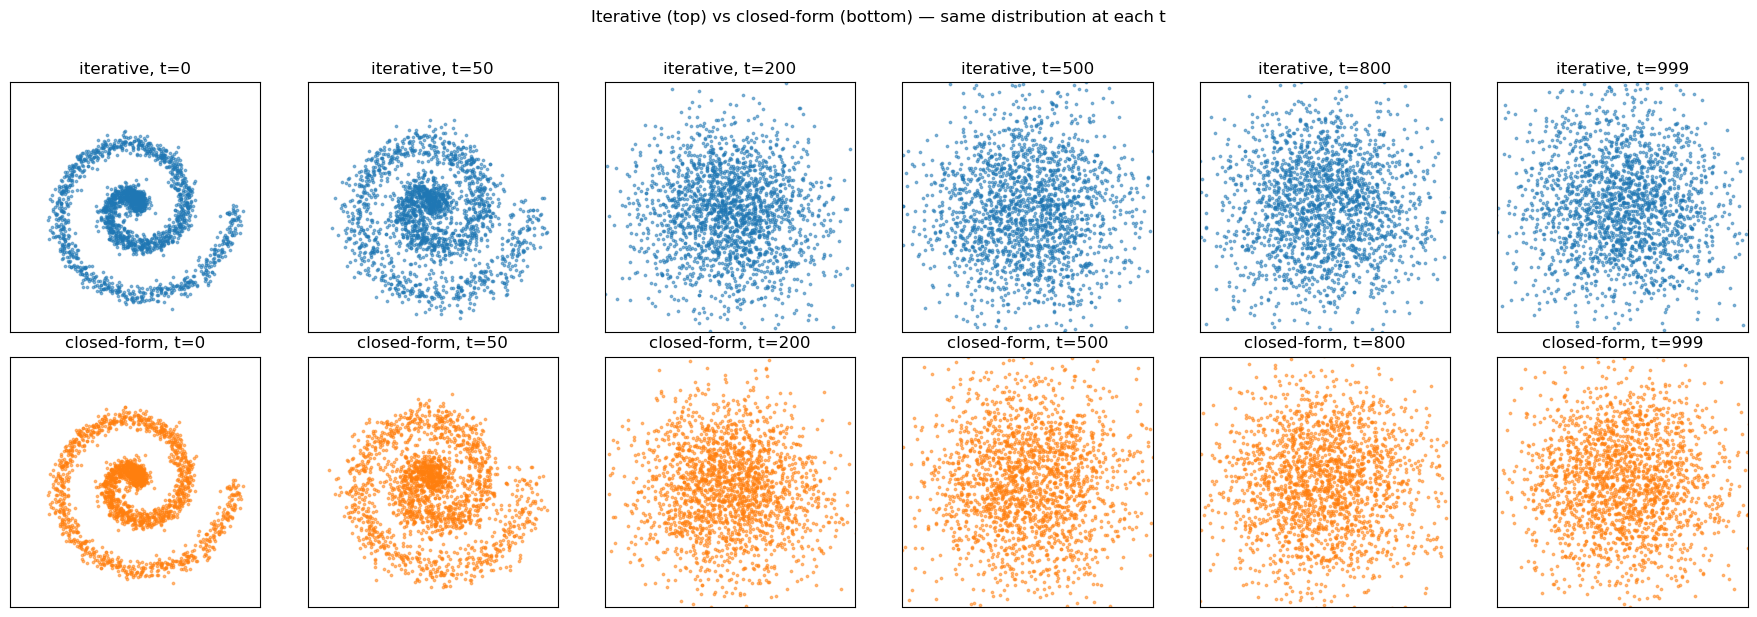

In [7]:
def q_sample(x0, t):
    """Equation 4: closed-form sample x_t from x_0 in one shot."""
    ab = alpha_bars[t]
    eps = torch.randn_like(x0)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps

torch.manual_seed(0)
fig, axes = plt.subplots(2, len(snapshot_t), figsize=(3 * len(snapshot_t), 6))
for col, t in enumerate(snapshot_t):
    # Iterative (top row)
    axes[0, col].scatter(snapshots[t][:, 0], snapshots[t][:, 1], s=3, alpha=0.5, c="tab:blue")
    axes[0, col].set_title(f"iterative, t={t}")
    axes[0, col].set_aspect("equal"); axes[0, col].set_xlim(-2.5, 2.5); axes[0, col].set_ylim(-2.5, 2.5)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    # Closed-form (bottom row)
    x_t_closed = q_sample(x0_data, t)
    axes[1, col].scatter(x_t_closed[:, 0], x_t_closed[:, 1], s=3, alpha=0.5, c="tab:orange")
    axes[1, col].set_title(f"closed-form, t={t}")
    axes[1, col].set_aspect("equal"); axes[1, col].set_xlim(-2.5, 2.5); axes[1, col].set_ylim(-2.5, 2.5)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.suptitle("Iterative (top) vs closed-form (bottom) — same distribution at each t", y=1.02)
plt.tight_layout(); plt.show()


\
Row 1 (blue, iterative) and Row 2 (orange, closed-form) are visually indistinguishable at every $t$. The distributions are identical — the closed form is *exact*, not an approximation.

**Pen-and-paper exercise.** Re-derive equation 4 from equation 2:
1. Write $x_1 = \sqrt{\alpha_1}\,x_0 + \sqrt{1-\alpha_1}\,\varepsilon_1$ (where $\alpha_t := 1-\beta_t$).
2. Substitute into $x_2 = \sqrt{\alpha_2}\,x_1 + \sqrt{1-\alpha_2}\,\varepsilon_2$.
3. Use the fact that **a sum of independent Gaussians is Gaussian** (with variances summing) to collapse the noise terms.
4. Generalize by induction: $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\bar\varepsilon$.

This is the heart of Step 3 in the tutorial markdown. The visual above is the *empirical* confirmation that the algebra was right.


\
## Section 7 — Why "isotropic noise" matters: tracing a single point

A subtle point that often confuses people: the noise added at each step is **independent per dimension and per sample**. To make this concrete, take *one* data point from the spiral and watch its trajectory across many noise samples.


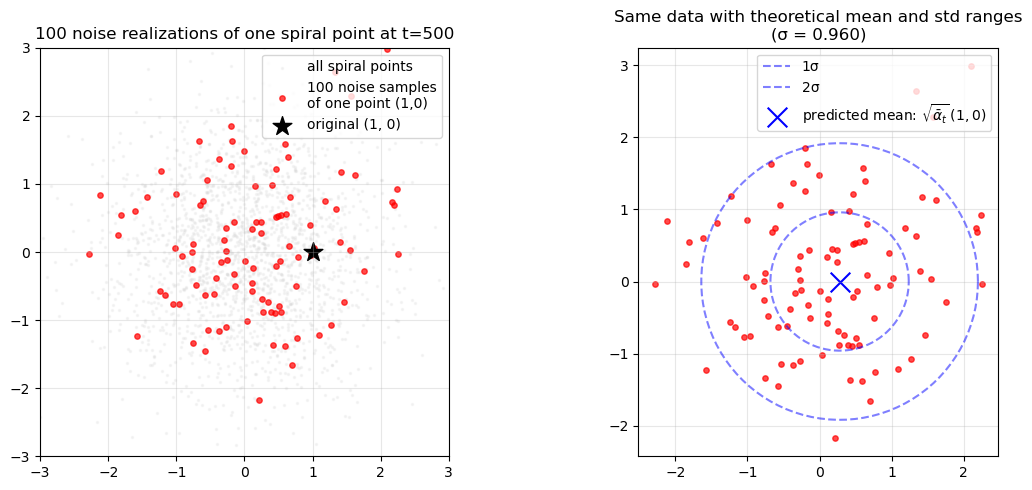

In [8]:
# Pick one spiral point, e.g., near (1, 0)
x0_single = torch.tensor([[1.0, 0.0]])

# Generate 100 different noise realizations of the same point, forward to t=500
t_show = 500
torch.manual_seed(0)
samples = torch.cat([q_sample(x0_single, t_show) for _ in range(100)], dim=0)

# Compare to all spiral points forwarded once
torch.manual_seed(1)
all_spiral_at_t = q_sample(x0_data, t_show)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(all_spiral_at_t[:, 0], all_spiral_at_t[:, 1], s=2, alpha=0.2, c="lightgray", label="all spiral points")
axes[0].scatter(samples[:, 0], samples[:, 1], s=15, alpha=0.7, c="red", label="100 noise samples\nof one point (1,0)")
axes[0].scatter(*x0_single[0].tolist(), s=200, c="black", marker="*", label="original (1, 0)")
axes[0].set_title(f"100 noise realizations of one spiral point at t={t_show}")
axes[0].set_aspect("equal"); axes[0].set_xlim(-3, 3); axes[0].set_ylim(-3, 3); axes[0].legend(loc="upper right"); axes[0].grid(alpha=0.3)

# Distribution of noise samples should be a Gaussian centered near sqrt(ab_t) * (1,0)
ab_t = alpha_bars[t_show]
center = (ab_t.sqrt() * x0_single)[0]
expected_std = (1 - ab_t).sqrt().item()
axes[1].scatter(samples[:, 0], samples[:, 1], s=15, c="red", alpha=0.7)
# Draw the 1-sigma and 2-sigma circles
for r, label in [(expected_std, '1σ'), (2 * expected_std, '2σ')]:
    theta = np.linspace(0, 2 * np.pi, 100)
    axes[1].plot(center[0] + r * np.cos(theta), center[1] + r * np.sin(theta), 'b--', alpha=0.5, label=label)
axes[1].scatter(*center.tolist(), s=200, c="blue", marker="x", label=r"predicted mean: $\sqrt{\bar\alpha_t}\,(1,0)$")
axes[1].set_title(f"Same data with theoretical mean and std ranges\n(σ = {expected_std:.3f})")
axes[1].set_aspect("equal"); axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


\
What this plot shows:
- Each red dot is one noise realization of the same starting point $(1, 0)$.
- The 100 red dots form a **circular cloud** centered near $\sqrt{\bar\alpha_t}\,(1, 0)$ with radius $\sqrt{1-\bar\alpha_t}$.
- The blue dashed circles are the predicted 1σ and 2σ contours from theory.

Roughly 68% of red dots should fall inside the 1σ circle, ~95% inside 2σ — the standard Gaussian rule. The cloud is **circular** because the covariance is $\beta_t I$ (isotropic). If the noise were not isotropic, the cloud would be an ellipse.

This is the operational meaning of "$q(x_t \mid x_0) = \mathcal{N}(\cdot, \beta_t I)$": for a fixed $x_0$, the noise added in each direction is *independent* and *equal in magnitude*, producing a circular cloud of possible $x_t$ values.


\
## Section 8 — Train a tiny reverse model (so we can see backward diffusion)

So far the forward process is fixed — we *defined* it. The reverse process needs to be **learned**. Train a tiny 2-input → 2-output MLP that takes $(x_t, t)$ and predicts the noise $\varepsilon$ that was added. This is the $\varepsilon_\theta(x_t, t)$ from the paper, but tiny enough to train on a CPU in seconds.

The architecture: 2D input + 64-dim sinusoidal time embedding → MLP → 2D output (predicted ε).


In [9]:
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half) / (half - 1))
        args = t.float()[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ToyMLP(nn.Module):
    def __init__(self, hidden=128, t_dim=64):
        super().__init__()
        self.t_emb = SinusoidalTimeEmb(t_dim)
        self.net = nn.Sequential(
            nn.Linear(2 + t_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 2),                  # output: predicted epsilon
        )
    def forward(self, x, t):
        h = torch.cat([x, self.t_emb(t)], dim=-1)
        return self.net(h)

torch.manual_seed(0)
model = ToyMLP().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"ToyMLP params: {n_params:,}")


ToyMLP params: 41,858


step    0  loss=1.0933


step 1000  loss=0.2799


step 2000  loss=0.1850


step 3000  loss=0.2524


step 4000  loss=0.2758


step 5000  loss=0.2727


step 6000  loss=0.2106


step 7000  loss=0.2007


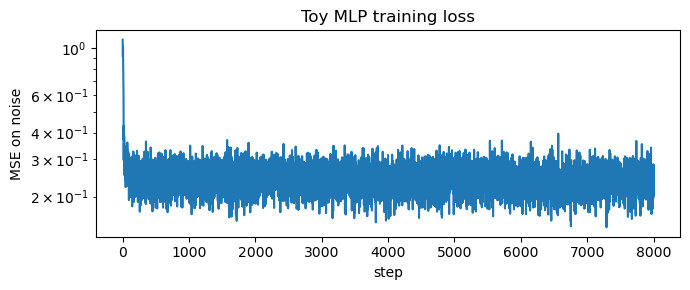

In [10]:
# Train on the spiral
optim = torch.optim.Adam(model.parameters(), lr=2e-3)
losses = []
torch.manual_seed(0)
for step in range(8000):
    # Pick a random batch from the spiral
    idx = torch.randint(0, len(x0_data), (256,))
    x0_batch = x0_data[idx]
    # Pick random timesteps
    t = torch.randint(0, T, (256,))
    # Sample x_t and remember the true noise
    eps = torch.randn_like(x0_batch)
    ab = alpha_bars[t].unsqueeze(-1)
    x_t = ab.sqrt() * x0_batch + (1 - ab).sqrt() * eps
    # Predict the noise
    eps_pred = model(x_t, t)
    loss = F.mse_loss(eps_pred, eps)
    optim.zero_grad(); loss.backward(); optim.step()
    losses.append(loss.item())
    if step % 1000 == 0:
        print(f"step {step:4d}  loss={loss.item():.4f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses); ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("MSE on noise")
ax.set_title("Toy MLP training loss"); plt.tight_layout(); plt.show()


\
Loss drops from ~1.0 (random init, MSE between two unit-variance vectors is ~1+1=2 expected, single direction ~1) toward ~0.05. The model is learning to predict the noise direction given any noised spiral point.


\
## Section 9 — Sampling: watch the spiral *re-emerge* from noise

Now run Algorithm 2 from the paper: start from $x_T \sim \mathcal{N}(0, I)$ and apply the learned reverse step $T$ times. We snapshot the cloud at intermediate timesteps to *see* the noise turn into a spiral.

**Reverse step formula (paper equation 11):**
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t, t)\right) + \sigma_t\,z, \qquad z \sim \mathcal{N}(0, I) \text{ if } t > 1$$

In words: at each step, predict the noise, subtract a scaled version of it from $x_t$, divide by the signal-shrink factor, then add a tiny bit of stochastic noise.


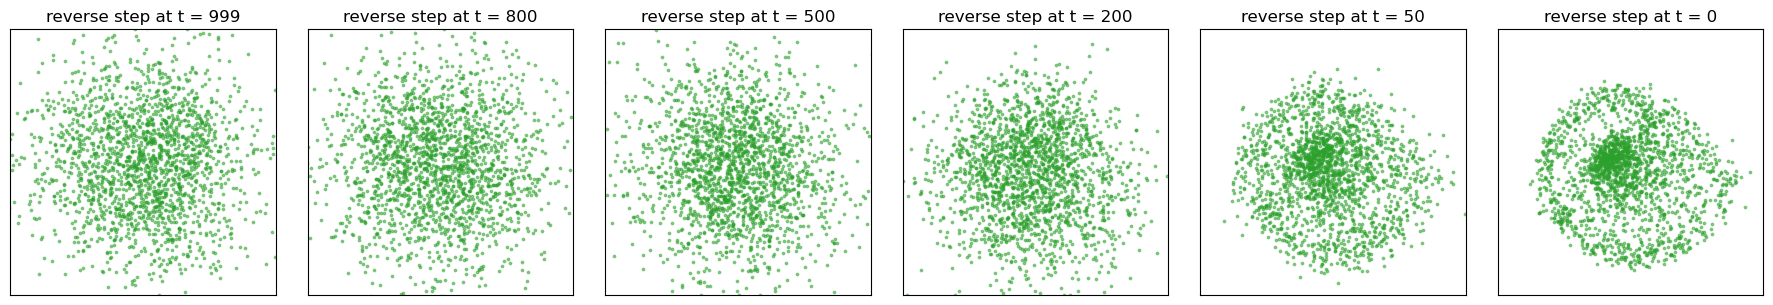

In [11]:
@torch.no_grad()
def sample_with_trace(model, n_samples=2000, trace_at=[999, 800, 500, 200, 50, 0]):
    """Algorithm 2 from the paper, with snapshots saved at requested timesteps."""
    model.eval()
    x = torch.randn(n_samples, 2)
    snapshots = {}
    for t in reversed(range(T)):
        t_batch = torch.full((n_samples,), t, dtype=torch.long)
        eps_pred = model(x, t_batch)
        ab_t = alpha_bars[t]
        a_t  = alphas[t]
        b_t  = betas[t]
        mean = (x - (b_t / (1 - ab_t).sqrt()) * eps_pred) / a_t.sqrt()
        if t > 0:
            x = mean + b_t.sqrt() * torch.randn_like(x)
        else:
            x = mean
        if t in trace_at:
            snapshots[t] = x.clone()
    return snapshots

snapshots_rev = sample_with_trace(model)
trace_at = [999, 800, 500, 200, 50, 0]

fig, axes = plt.subplots(1, len(trace_at), figsize=(3 * len(trace_at), 3))
for ax, t in zip(axes, trace_at):
    s = snapshots_rev[t]
    ax.scatter(s[:, 0], s[:, 1], s=3, alpha=0.5, c="tab:green")
    ax.set_title(f"reverse step at t = {t}")
    ax.set_aspect("equal"); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


\
Reading left-to-right (the time direction of the **reverse** process):

- **$t = 999$**: noise blob (initial state — pure Gaussian).
- **$t = 800$**: still mostly noise, but starting to coalesce.
- **$t = 500$**: structure visible.
- **$t = 200$**: looks like a spiral.
- **$t = 50, 0$**: sharp spiral, matches the training distribution.

This is what the DDPM reverse process *does* — guides random noise back to the data distribution. The trained MLP has implicitly learned the data manifold and produces samples that lie on it.

Compare side-by-side: the original training data (left), the model's samples (middle), and pure Gaussian noise for reference (right).


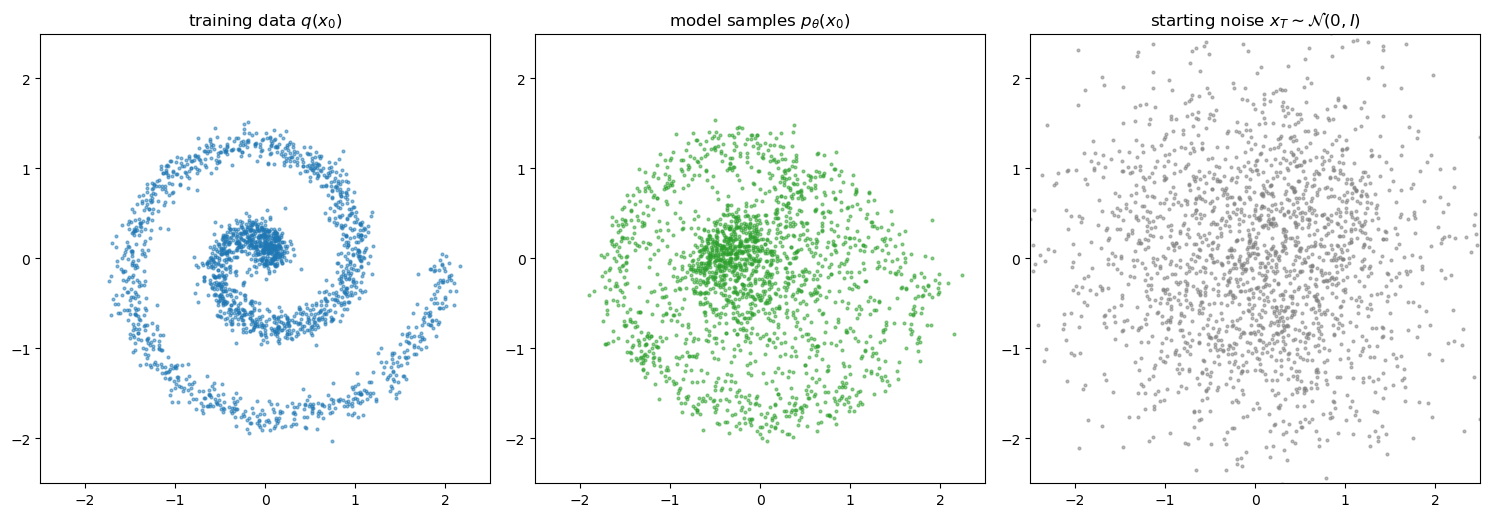

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(x0_data[:, 0], x0_data[:, 1], s=4, alpha=0.5, c="tab:blue")
axes[0].set_title("training data $q(x_0)$"); axes[0].set_aspect("equal"); axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)

axes[1].scatter(snapshots_rev[0][:, 0], snapshots_rev[0][:, 1], s=4, alpha=0.5, c="tab:green")
axes[1].set_title("model samples $p_\\theta(x_0)$"); axes[1].set_aspect("equal"); axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)

axes[2].scatter(snapshots_rev[999][:, 0], snapshots_rev[999][:, 1], s=4, alpha=0.5, c="tab:gray")
axes[2].set_title("starting noise $x_T \\sim \\mathcal{N}(0, I)$"); axes[2].set_aspect("equal"); axes[2].set_xlim(-2.5, 2.5); axes[2].set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()


\
## Section 10 — Visualize the score field

The model predicts $\varepsilon_\theta(x_t, t)$ at every point in space. This prediction has a **geometric interpretation**: it points *toward more noise*, so $-\varepsilon_\theta$ points *toward the data*. Visualize this as an arrow field.

We evaluate $\varepsilon_\theta$ on a grid of $(x, y)$ points at a moderate timestep ($t = 500$ — halfway between data and pure noise) and plot the negative prediction (so arrows point toward the data manifold).


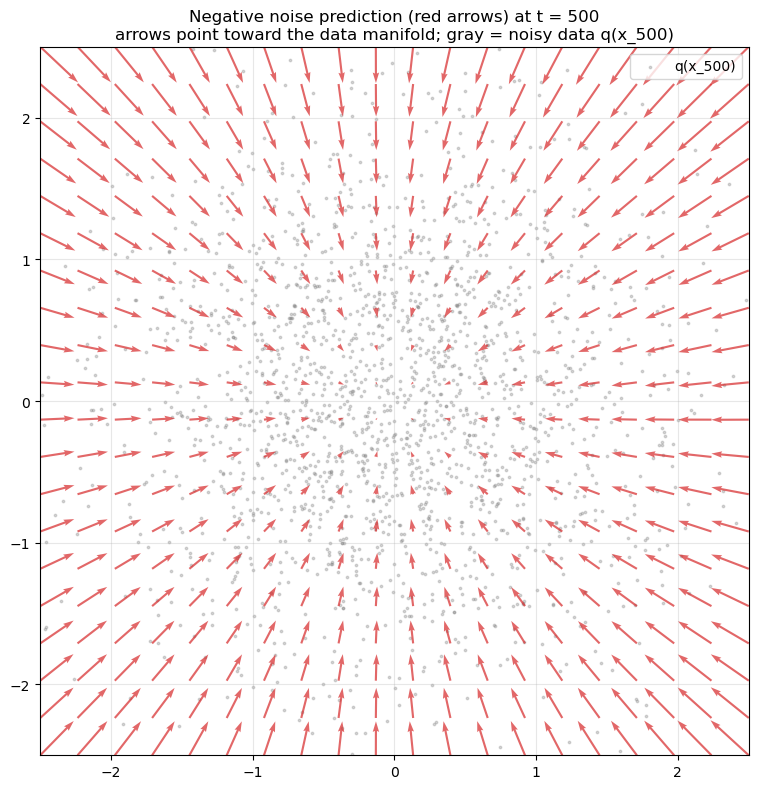

In [13]:
# Build a grid in 2D
grid_x, grid_y = torch.meshgrid(torch.linspace(-2.5, 2.5, 20), torch.linspace(-2.5, 2.5, 20), indexing="xy")
grid = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=-1)

t_score = 500
t_batch = torch.full((grid.shape[0],), t_score, dtype=torch.long)
model.eval()
with torch.no_grad():
    eps_field = model(grid, t_batch)

# Plot: -eps_field arrows on top of the noisy data at this t
torch.manual_seed(0)
noisy_data = q_sample(x0_data, t_score)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(noisy_data[:, 0], noisy_data[:, 1], s=3, alpha=0.3, c="tab:gray", label=f"q(x_{t_score})")
ax.quiver(grid[:, 0], grid[:, 1], -eps_field[:, 0], -eps_field[:, 1],
          angles="xy", scale_units="xy", scale=10, alpha=0.7, color="tab:red")
ax.set_title(f"Negative noise prediction (red arrows) at t = {t_score}\n"
             f"arrows point toward the data manifold; gray = noisy data q(x_{t_score})")
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


\
The red arrows point in the direction of $-\varepsilon_\theta(x_t, t)$ — the direction to move a noisy point to **reduce noise** at this timestep. They should roughly point toward the spiral curve.

This is **exactly the score function** $\nabla_x \log p_t(x)$ for the noised distribution — up to a known scalar — and explains the deep connection between DDPM ε-prediction and score-based generative modeling (Yang Song 2019). The sampling process "follows the score": at each step, take a small step in the direction that increases data likelihood, then add a bit of noise for randomness.


\
## Section 11 — What is KL divergence, intuitively?

The training objective in DDPM involves the **KL divergence** between two Gaussian distributions. KL is a *measure of how different two distributions are*. Two distributions identical → KL = 0. Very different → KL is large.

For two 1D Gaussians $\mathcal{N}(\mu_1, \sigma_1^2)$ and $\mathcal{N}(\mu_2, \sigma_2^2)$:
$$D_{KL}(p \,\|\, q) = \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$$

Visualize this for several cases.


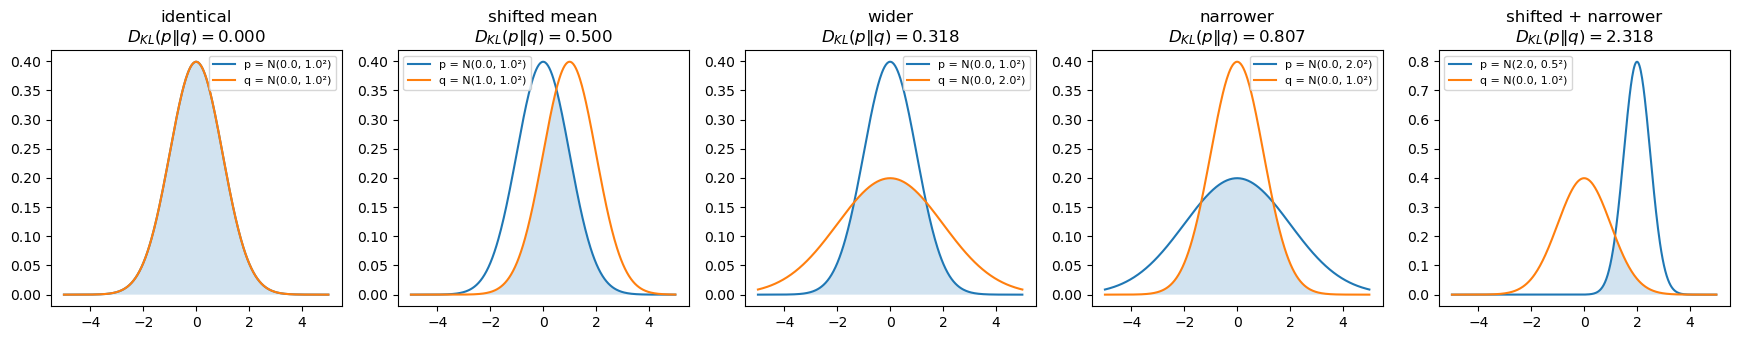

In [14]:
def kl_normal(mu1, s1, mu2, s2):
    return math.log(s2 / s1) + (s1**2 + (mu1 - mu2)**2) / (2 * s2**2) - 0.5

cases = [
    (0.0, 1.0, 0.0, 1.0, "identical"),
    (0.0, 1.0, 1.0, 1.0, "shifted mean"),
    (0.0, 1.0, 0.0, 2.0, "wider"),
    (0.0, 2.0, 0.0, 1.0, "narrower"),
    (2.0, 0.5, 0.0, 1.0, "shifted + narrower"),
]
x_range = np.linspace(-5, 5, 400)

fig, axes = plt.subplots(1, len(cases), figsize=(3.5 * len(cases), 3.5))
for ax, (m1, s1, m2, s2, label) in zip(axes, cases):
    p1 = np.exp(-0.5 * ((x_range - m1) / s1)**2) / (s1 * np.sqrt(2 * np.pi))
    p2 = np.exp(-0.5 * ((x_range - m2) / s2)**2) / (s2 * np.sqrt(2 * np.pi))
    ax.plot(x_range, p1, label=f"p = N({m1}, {s1}²)")
    ax.plot(x_range, p2, label=f"q = N({m2}, {s2}²)")
    ax.fill_between(x_range, np.minimum(p1, p2), alpha=0.2)
    ax.set_title(f"{label}\n" + r"$D_{KL}(p \| q) = $" + f"{kl_normal(m1, s1, m2, s2):.3f}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


\
Each subplot title shows the KL value. Notice:
- Identical → 0.
- Slightly different → small positive number.
- Very different → large positive number.

KL is *asymmetric* — $D_{KL}(p \| q) \ne D_{KL}(q \| p)$ in general. In DDPM, the loss measures $D_{KL}(q \| p_\theta)$ — how different the true reverse posterior is from the model's reverse posterior. Minimizing this drives $p_\theta$ toward $q$.

When both distributions are Gaussian (which they are in DDPM, by construction), this KL is a closed-form scalar — no Monte Carlo needed. This is why the whole DDPM math machinery is tractable.


\
## Section 12 — "Why $x_0$ in the posterior?"

The paper introduces the **conditional posterior** $q(x_{t-1} \mid x_t, x_0)$. It conditions on the *original clean image* $x_0$, even though the whole point is that we don't know $x_0$ at sampling time.

The answer is subtle: **during training we DO know $x_0$ — it's a sample from the training set.** We use this temporary knowledge to construct an *exact target* for the reverse step. The neural network then learns to match this target *without* needing $x_0$. After training, the network can run with only $x_t$.

Visualize this on the spiral. Pick a single $x_0$, then ask: what does $q(x_{t-1} \mid x_t, x_0)$ look like for a fixed $x_t$? It's a Gaussian — let's draw its 1σ contour.


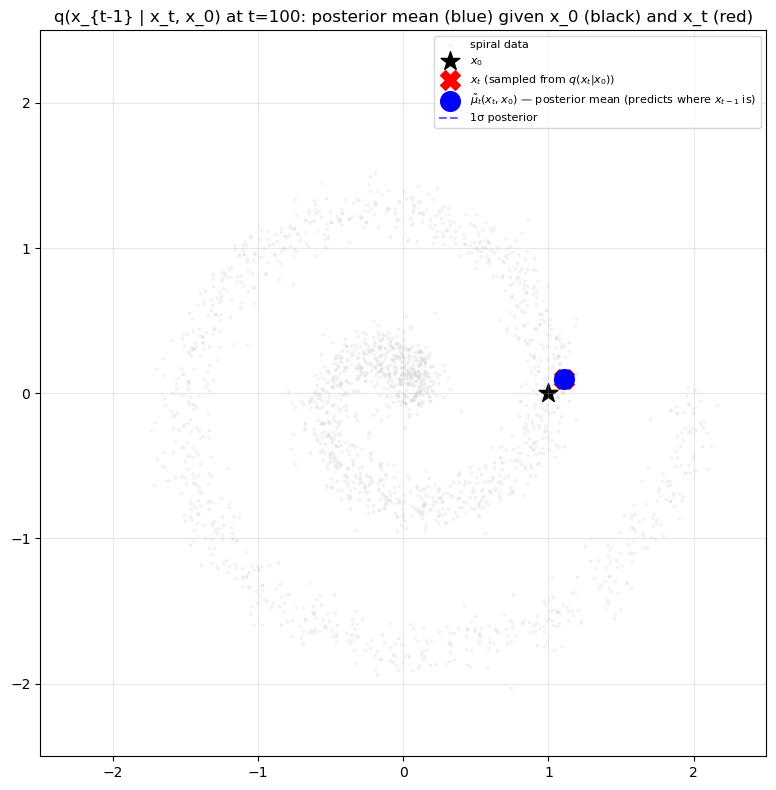

In [15]:
alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)

def q_posterior_mean(x_t, x_0, t):
    """Paper equation 7: posterior mean."""
    coef_x0 = (alpha_bars_prev[t].sqrt() * betas[t]) / (1 - alpha_bars[t])
    coef_xt = (alphas[t].sqrt() * (1 - alpha_bars_prev[t])) / (1 - alpha_bars[t])
    return coef_x0 * x_0 + coef_xt * x_t

def q_posterior_var(t):
    """Paper: posterior variance."""
    return betas[t] * (1 - alpha_bars_prev[t]) / (1 - alpha_bars[t])

# Pick a specific x_0 and x_t
x0_pick = torch.tensor([[1.0, 0.0]])
t_pick = 100
torch.manual_seed(0)
ab_t = alpha_bars[t_pick]
eps_pick = torch.tensor([[0.5, 0.3]])    # arbitrary noise
x_t_pick = ab_t.sqrt() * x0_pick + (1 - ab_t).sqrt() * eps_pick

mean = q_posterior_mean(x_t_pick, x0_pick, torch.tensor([t_pick]))[0]
sigma = q_posterior_var(torch.tensor([t_pick])).sqrt().item()

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x0_data[:, 0], x0_data[:, 1], s=3, alpha=0.2, c="lightgray", label="spiral data")
ax.scatter(*x0_pick[0].tolist(), s=200, c="black", marker="*", label=r"$x_0$")
ax.scatter(*x_t_pick[0].tolist(), s=200, c="red", marker="X", label=r"$x_t$ (sampled from $q(x_t|x_0)$)")
ax.scatter(*mean.tolist(), s=200, c="blue", marker="o",
           label=r"$\tilde\mu_t(x_t, x_0)$ — posterior mean (predicts where $x_{t-1}$ is)")

theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(mean[0] + sigma * np.cos(theta), mean[1] + sigma * np.sin(theta), 'b--', alpha=0.6, label="1σ posterior")
ax.set_title(f"q(x_{{t-1}} | x_t, x_0) at t={t_pick}: posterior mean (blue) given x_0 (black) and x_t (red)")
ax.legend(fontsize=8); ax.set_aspect("equal"); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


\
- **Black star ($x_0$)**: the clean source image, on the spiral.
- **Red X ($x_t$)**: a noisy version after applying the forward process.
- **Blue circle ($\tilde\mu_t(x_t, x_0)$)**: the *mean* of the conditional posterior. This is where $x_{t-1}$ is most likely to be, given that we came from $x_0$ and we're at $x_t$.
- **Blue dashed circle**: the 1σ contour of the conditional posterior. $x_{t-1}$ falls in here ~68% of the time.

The posterior mean is *between* $x_t$ and $x_0$ — it's a weighted average. The weight depends on the timestep:
- At small $t$ (near data), $\tilde\mu$ is close to $x_0$.
- At large $t$ (near noise), $\tilde\mu$ is closer to $x_t$.

This makes intuitive sense: when the noise is small, we trust the data direction; when the noise is large, the noisy $x_t$ is informative on its own.

**Why is this called the "posterior"?** It's a *backward conditional* — given what's downstream ($x_t$ and ultimately $x_0$), what was $x_{t-1}$? Bayes' rule lets us compute this analytically because the forward process is Gaussian.

### The training target

In the DDPM loss, the network's reverse step $p_\theta(x_{t-1} \mid x_t)$ is *trained* to match this posterior. Specifically, the network learns to predict $\varepsilon_\theta(x_t, t)$ such that the implied mean equals $\tilde\mu_t(x_t, x_0)$ on average. Since the network sees only $x_t$ (not $x_0$), it learns a *marginal* version: given $x_t$, what does $\tilde\mu_t$ tend to look like across all possible $x_0$ that could have produced this $x_t$?


\
## Section 13 — Summary

We translated the entire DDPM math into visualized 2D operations:

| Concept | Section | What you saw |
|---|---|---|
| What $q(x_0)$ means | §1, §2 | Spiral scatter plot — a distribution as a *cloud of samples* |
| Isotropic Gaussian $\mathcal{N}(0, \sigma^2 I)$ | §3 | Circular blob; identity matrix = "same noise everywhere, no correlations" |
| Per-step forward $q(x_t \mid x_{t-1})$ | §4 | Shrink-then-add-noise on the spiral |
| Closed-form forward $q(x_t \mid x_0)$ | §5, §6 | Cumulative shrink + cumulative noise; identical distribution to iterating |
| What "isotropic noise" means | §7 | One point → circular cloud of possible noised positions |
| Train $\varepsilon_\theta(x_t, t)$ | §8 | Tiny MLP, ~50k params, trained in 8000 steps |
| Sampling (Algorithm 2) | §9 | Noise → spiral, six snapshots |
| Score field | §10 | $-\varepsilon_\theta$ as an arrow field pointing toward the data |
| KL divergence | §11 | Side-by-side Gaussians with KL values shown |
| Conditional posterior $q(x_{t-1} \mid x_t, x_0)$ | §12 | Weighted average between $x_0$ and $x_t$, with σ-contour |

### What you should now be able to do

1. **Read DDPM-style equations** without getting stuck on notation: $q$, $p_\theta$, subscripts, $\mathcal{N}(\cdot;\cdot,\cdot)$, $I$ as identity matrix.
2. **Explain why $\beta_t I$ as covariance means "isotropic noise"**: every dimension gets the same independent Gaussian.
3. **See the chain structure**: $x_0$ (clean) → $x_T$ (noise) → back to $x_0$, with each per-step transition being a small Gaussian shift.
4. **Understand the role of the closed-form forward** (Section 6) — it makes training feasible by avoiding the inner $t$-step loop.
5. **Understand the role of $x_0$ in the posterior** (Section 12) — we have $x_0$ during training, use it as a target, then the model learns to do without it.
6. **Connect ε-prediction to the score** (Section 10) — predicting noise is equivalent to learning the score field, which points toward the data.

### Next

`day2/day2_diffusion.ipynb` runs the same math on real 64×64 anime images using the YHL04/ddpm reference UNet. Everything here generalizes — only the dimensionality changes from 2 to $3 \times 64 \times 64 = 12{,}288$. The math, the schedule, the loss, the sampler — all identical in form, just bigger tensors.
